# Exploratory Data Analysis: NASA MDP PC1

This notebook loads the original `data/raw/pc1.arff` dataset and investigates its structure, class distribution, software metrics, correlations, group differences, and potential outliers. No preprocessing, resampling, model training, or prediction is performed.

Loaded: h:\klu project\AI_Software_Defect_Prediction\data\raw\pc1.arff
Shape: (1109, 22)
Features: 21


,loc,v(g),ev(g),iv(G),N,V,L,D,I,E,...,lOCode,lOComment,locCodeAndComment,lOBlank,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2.0,2.0,2.0,2.0,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,True
2,91.0,9.0,3.0,2.0,318.0,2089.21,0.04,27.68,75.47,57833.24,...,80.0,44.0,11.0,31.0,29.0,66.0,192.0,126.0,17.0,True
3,109.0,21.0,5.0,18.0,381.0,2547.56,0.04,28.37,89.79,72282.68,...,97.0,41.0,12.0,24.0,28.0,75.0,229.0,152.0,38.0,True
4,505.0,106.0,41.0,82.0,2339.0,20696.93,0.01,75.93,272.58,1571506.88,...,457.0,71.0,48.0,49.0,64.0,397.0,1397.0,942.0,178.0,True


,loc,v(g),ev(g),iv(G),N,V,L,D,I,E,...,lOCode,lOComment,locCodeAndComment,lOBlank,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
1104,6.0,4.0,4.0,1.0,26.0,96.21,0.08,13.33,7.22,1282.82,...,6.0,0.0,0.0,2.0,10.0,3.0,18.0,8.0,7.0,False
1105,10.0,5.0,5.0,1.0,43.0,182.66,0.05,21.00,8.70,3835.88,...,10.0,0.0,0.0,1.0,14.0,5.0,28.0,15.0,9.0,False
1106,5.0,3.0,3.0,1.0,17.0,62.91,0.21,4.80,13.11,301.96,...,5.0,0.0,0.0,0.0,8.0,5.0,11.0,6.0,5.0,False
1107,18.0,8.0,5.0,5.0,111.0,613.12,0.04,22.92,26.75,14050.56,...,18.0,0.0,0.0,1.0,22.0,24.0,61.0,50.0,15.0,False
1108,26.0,18.0,13.0,6.0,228.0,1335.62,0.03,35.81,37.29,47834.26,...,26.0,0.0,0.0,1.0,23.0,35.0,119.0,109.0,35.0,False


,dtype
loc,float64
v(g),float64
ev(g),float64
iv(G),float64
N,float64
V,float64
L,float64
D,float64
I,float64
E,float64


<class 'pandas.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                1109 non-null   float64
 1   v(g)               1109 non-null   float64
 2   ev(g)              1109 non-null   float64
 3   iv(G)              1109 non-null   float64
 4   N                  1109 non-null   float64
 5   V                  1109 non-null   float64
 6   L                  1109 non-null   float64
 7   D                  1109 non-null   float64
 8   I                  1109 non-null   float64
 9   E                  1109 non-null   float64
 10  B                  1109 non-null   float64
 11  T                  1109 non-null   float64
 12  lOCode             1109 non-null   float64
 13  lOComment          1109 non-null   float64
 14  locCodeAndComment  1109 non-null   float64
 15  lOBlank            1109 non-null   float64
 16  uniq_Op            1109 non-null   

,count,percentage
defects,,
Non-defective,1032,93.06
Defective,77,6.94


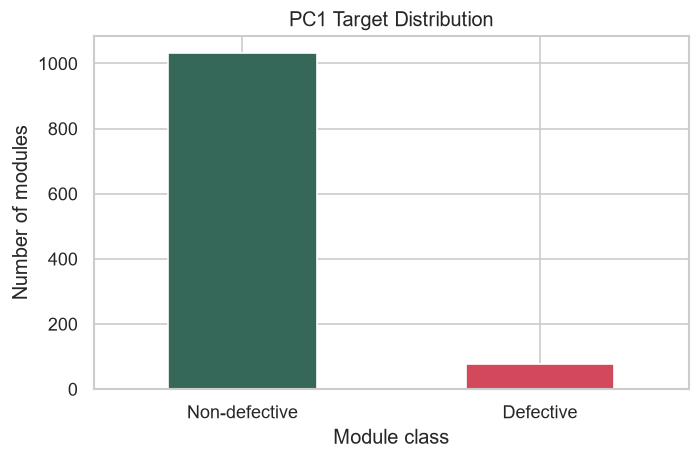

The target is strongly imbalanced; defective modules are the minority class.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import arff
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
project_root = Path.cwd()
if not (project_root / "data/raw/pc1.arff").exists():
    project_root = Path("h:/klu project/AI_Software_Defect_Prediction")
raw_path = project_root / "data/raw/pc1.arff"
figure_dir = project_root / "reports/figures"
figure_dir.mkdir(parents=True, exist_ok=True)
records, _ = arff.loadarff(raw_path)
df = pd.DataFrame(records)
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.decode("utf-8")
target = "defects"
df[target] = df[target].astype(str).str.lower().map({"true": True, "false": False})
features = [column for column in df.columns if column != target]
numeric_df = df[features].apply(pd.to_numeric, errors="coerce")
print("Loaded:", raw_path)
print("Shape:", df.shape)
print("Features:", len(features))
display(df.head())
display(df.tail())
display(df.dtypes.to_frame("dtype"))
df.info()
counts = df[target].value_counts().rename(index={False: "Non-defective", True: "Defective"})
percentages = (counts / len(df) * 100).round(2)
display(pd.DataFrame({"count": counts, "percentage": percentages}))
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#356859", "#d1495b"])
ax.set_title("PC1 Target Distribution")
ax.set_xlabel("Module class")
ax.set_ylabel("Number of modules")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(figure_dir / "target_distribution.png", bbox_inches="tight")
plt.show()
print("The target is strongly imbalanced; defective modules are the minority class.")

## Numerical summaries, data quality, distributions, group comparisons, correlations, and outliers

,count,mean,median,std,min,25%,50%,75%,max
loc,1109.0,23.3761,13.00,35.2840,0.0,7.00,13.00,26.00,602.00
v(g),1109.0,5.5107,3.00,8.9590,1.0,1.00,3.00,6.00,136.00
ev(g),1109.0,2.7668,1.00,5.5677,1.0,1.00,1.00,3.00,123.00
iv(G),1109.0,3.3214,2.00,6.4020,1.0,1.00,2.00,3.00,123.00
N,1109.0,117.3934,58.00,197.3369,1.0,25.00,58.00,126.00,2785.00
V,1109.0,699.7112,275.10,1509.5457,0.0,97.67,275.10,674.04,25942.69
L,1109.0,0.1294,0.08,0.1470,0.0,0.05,0.08,0.16,2.00
D,1109.0,15.3963,11.61,16.3375,0.0,5.71,11.61,20.50,270.66
I,1109.0,32.9045,23.57,35.3877,0.0,14.04,23.57,41.15,598.33
E,1109.0,28822.8824,3189.17,170643.6033,0.0,558.13,3189.17,12381.56,4279633.01


,observed_value
missing_values,0
duplicate_rows,155
infinite_values,0
constant_features,0
near_zero_variance_features,0


,range,skewness,coefficient_of_variation
E,4279633.01,18.5502,5.9204
T,237757.40,18.5502,5.9204
V,25942.69,8.4542,2.1574
N,2784.00,6.0561,1.6810
total_Op,1640.00,6.5478,1.6799
total_Opnd,1144.00,5.5070,1.6956
loc,602.00,7.5670,1.5094
lOCode,600.00,7.7926,1.4966
I,598.33,5.7946,1.0755
uniq_Opnd,538.00,7.9974,1.3905


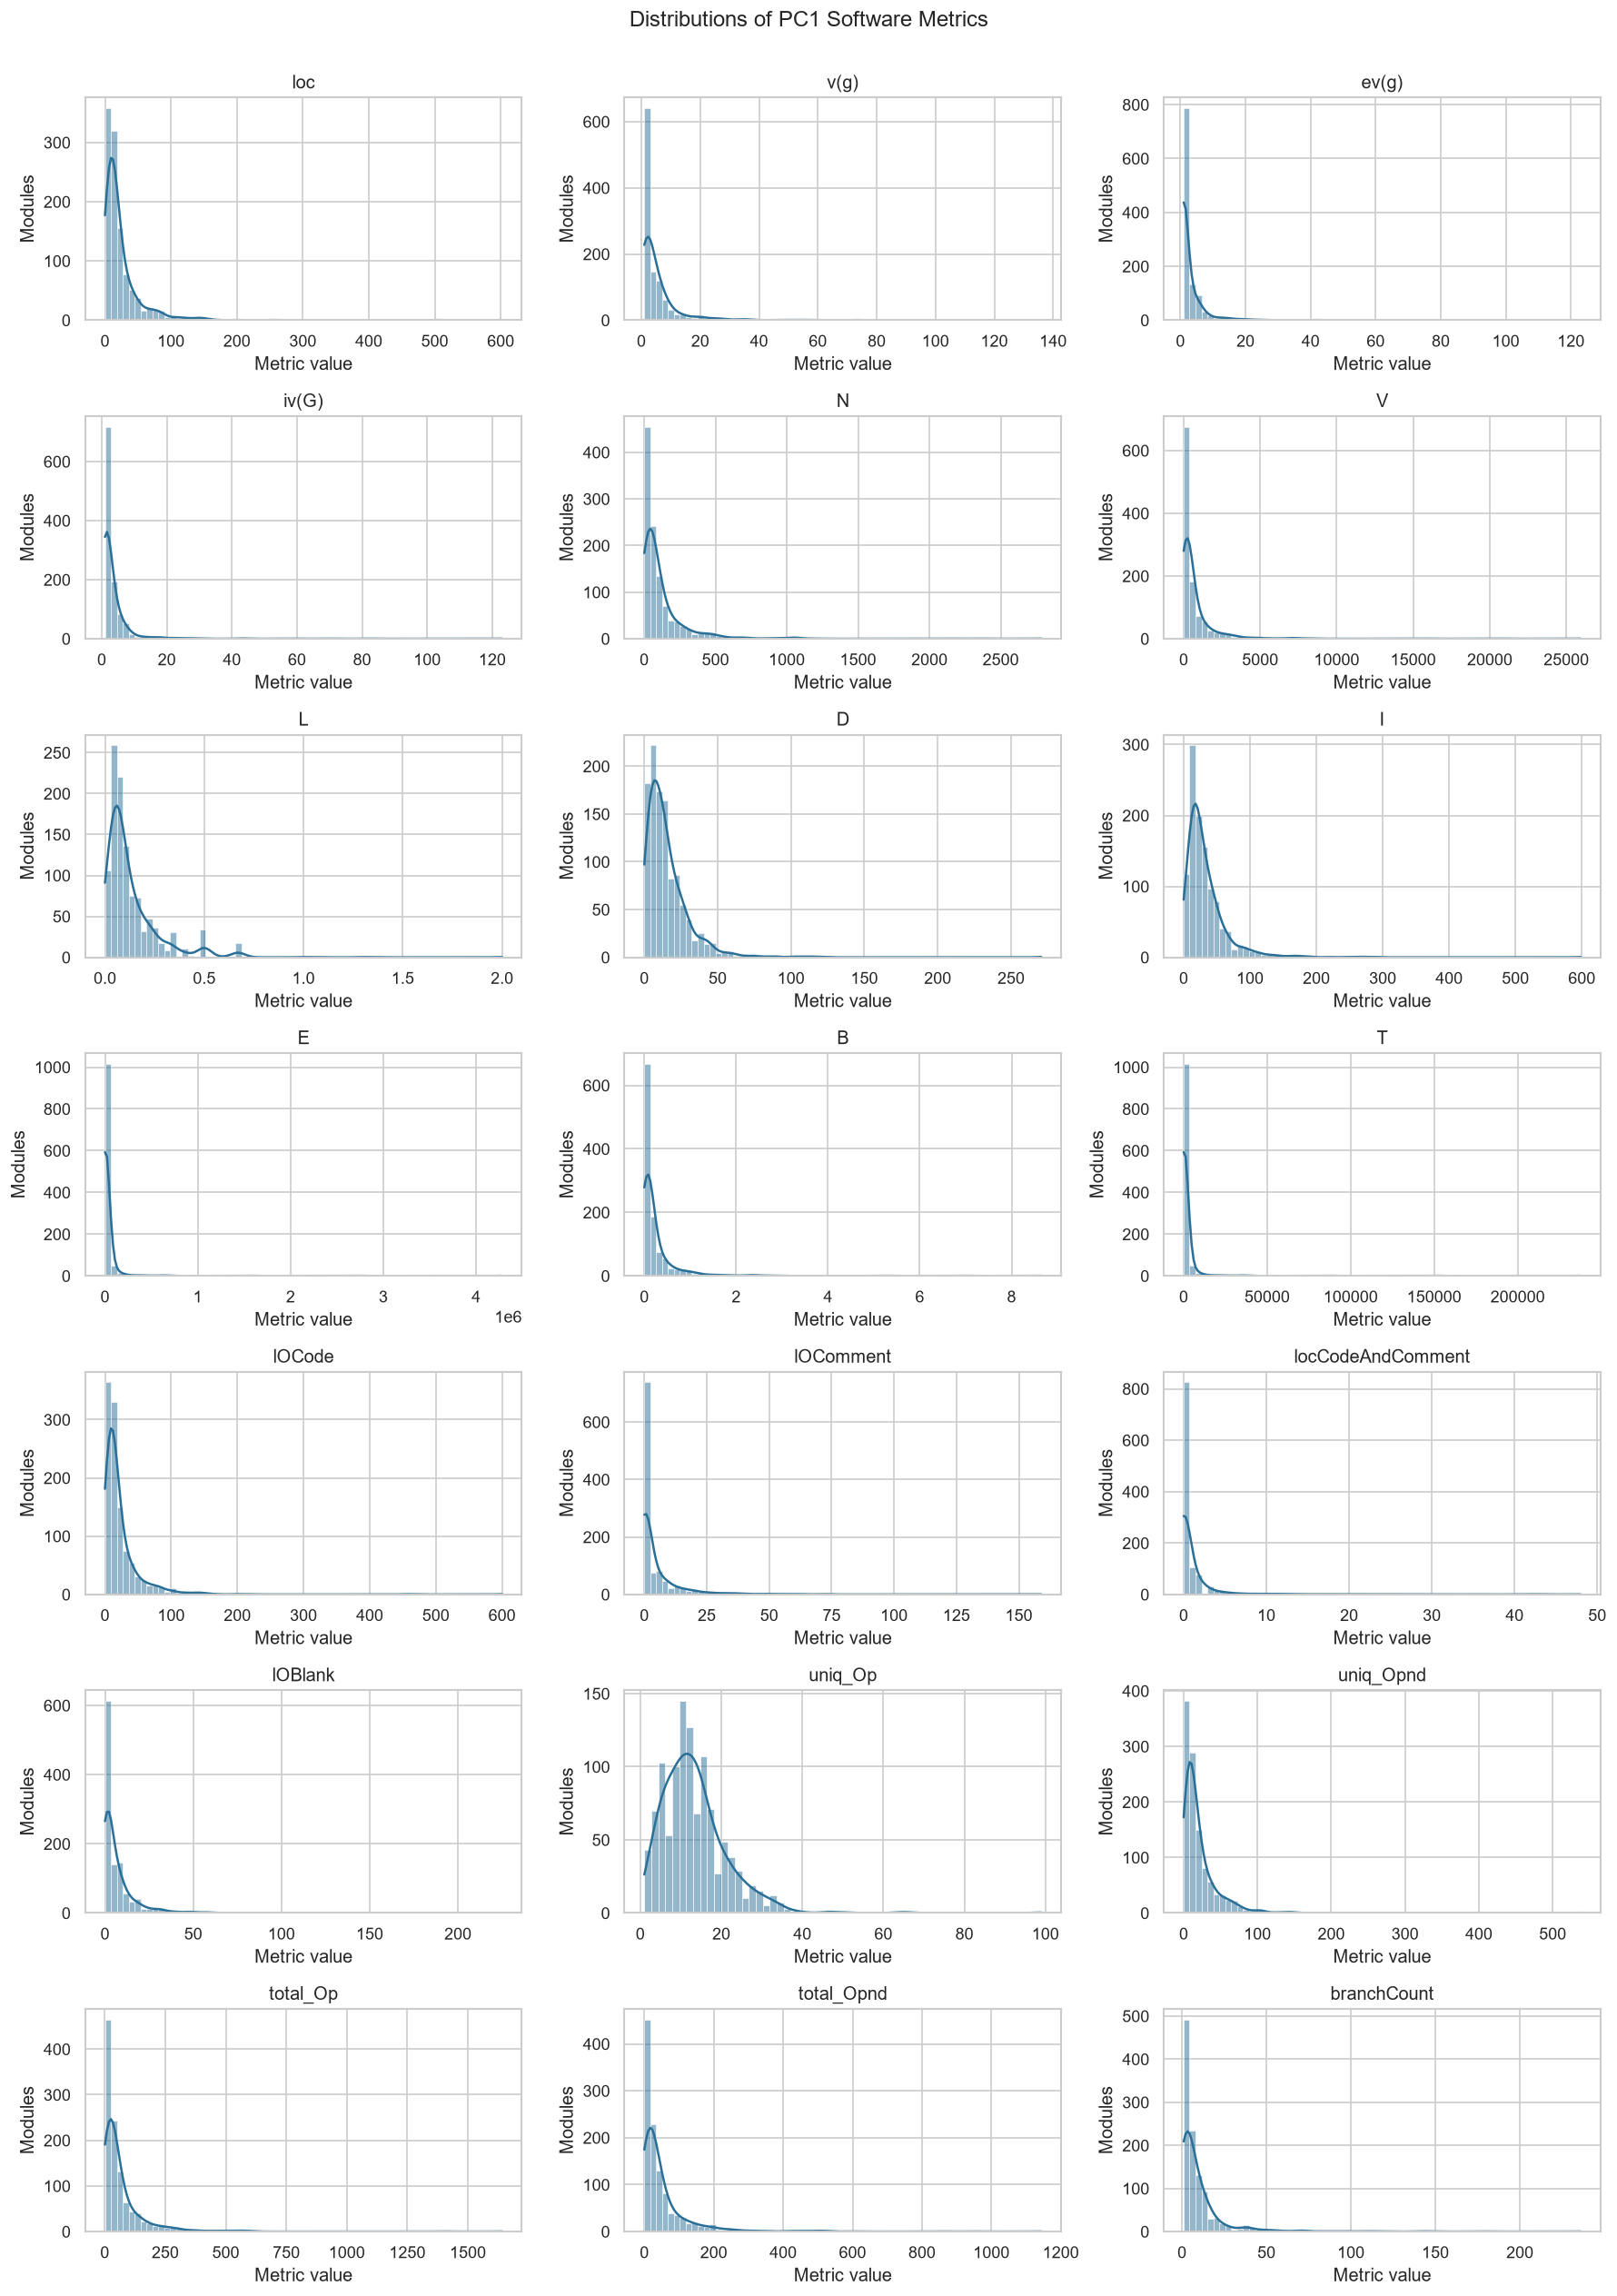

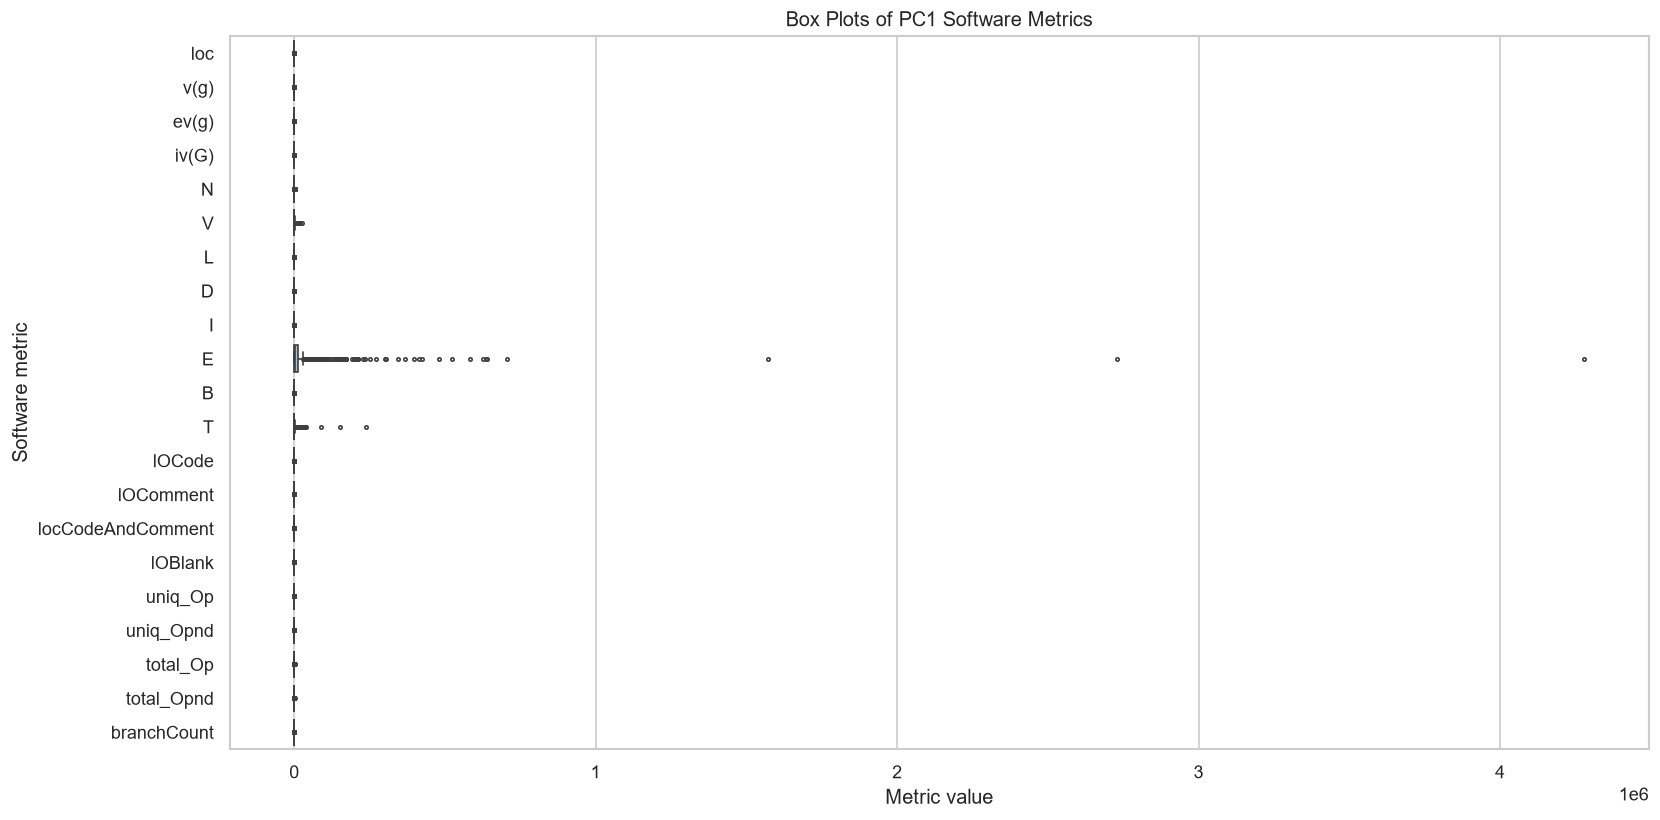

,outlier_count,outlier_percentage
T,163,14.70
E,163,14.70
lOComment,127,11.45
V,121,10.91
B,118,10.64
iv(G),115,10.37
lOCode,114,10.28
N,110,9.92
total_Op,108,9.74
loc,105,9.47


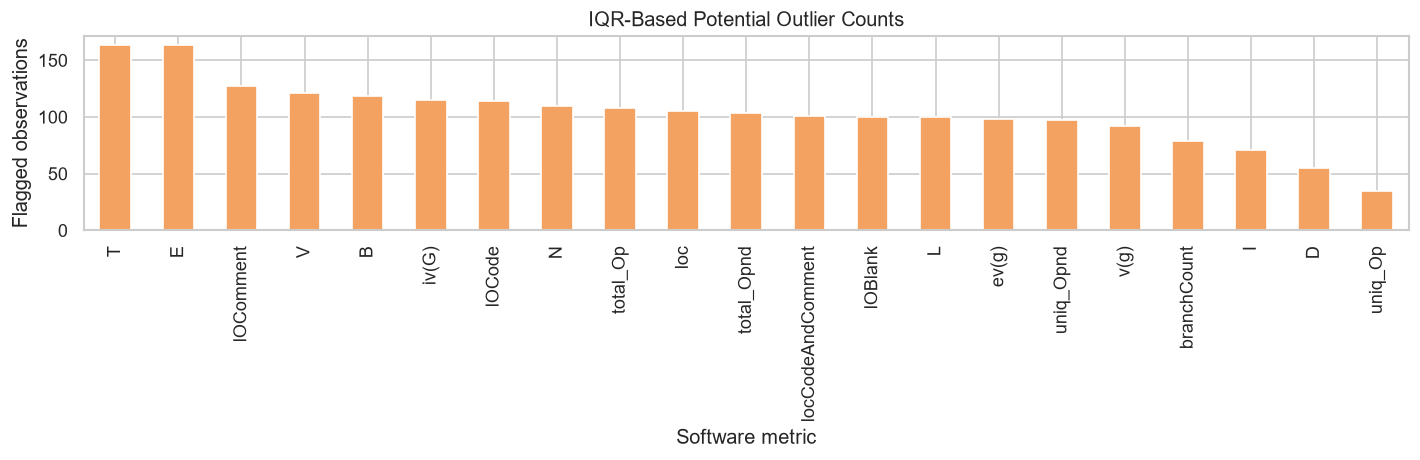

class_label,Defective,Non-defective,absolute_median_difference
E,10872.53,3023.230,7849.300
T,604.03,167.960,436.070
V,650.30,249.535,400.765
N,116.00,54.500,61.500
total_Op,66.00,31.000,35.000
total_Opnd,56.00,23.000,33.000


,feature,defective_median,non_defective_median,mann_whitney_u,p_value
15,lOBlank,11.00,2.000,60004.0,0.0
8,I,43.87,21.895,59755.5,0.0
17,uniq_Opnd,30.00,12.000,58660.0,0.0
14,locCodeAndComment,1.00,0.000,53173.5,0.0
13,lOComment,6.00,0.000,54855.5,0.0
0,loc,29.00,12.000,56138.5,0.0
10,B,0.24,0.080,55855.0,0.0
12,lOCode,28.00,12.000,55559.0,0.0
5,V,650.30,249.535,54992.0,0.0
19,total_Opnd,56.00,23.000,54590.0,0.0


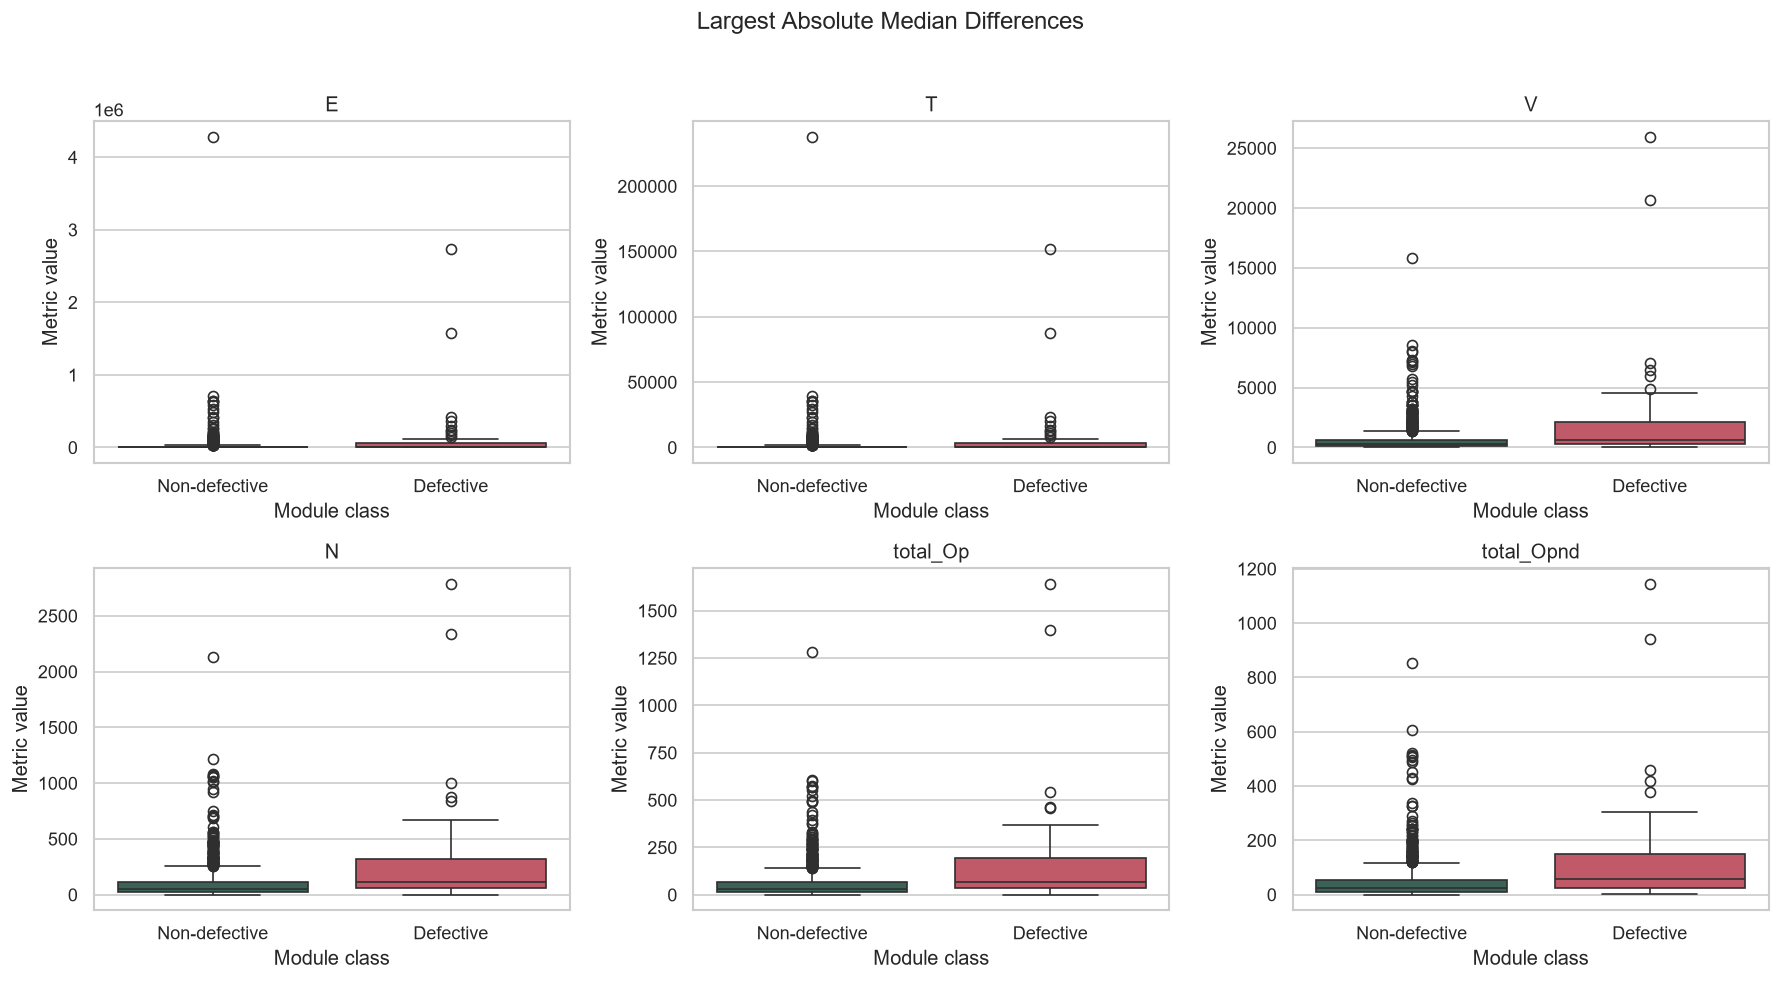

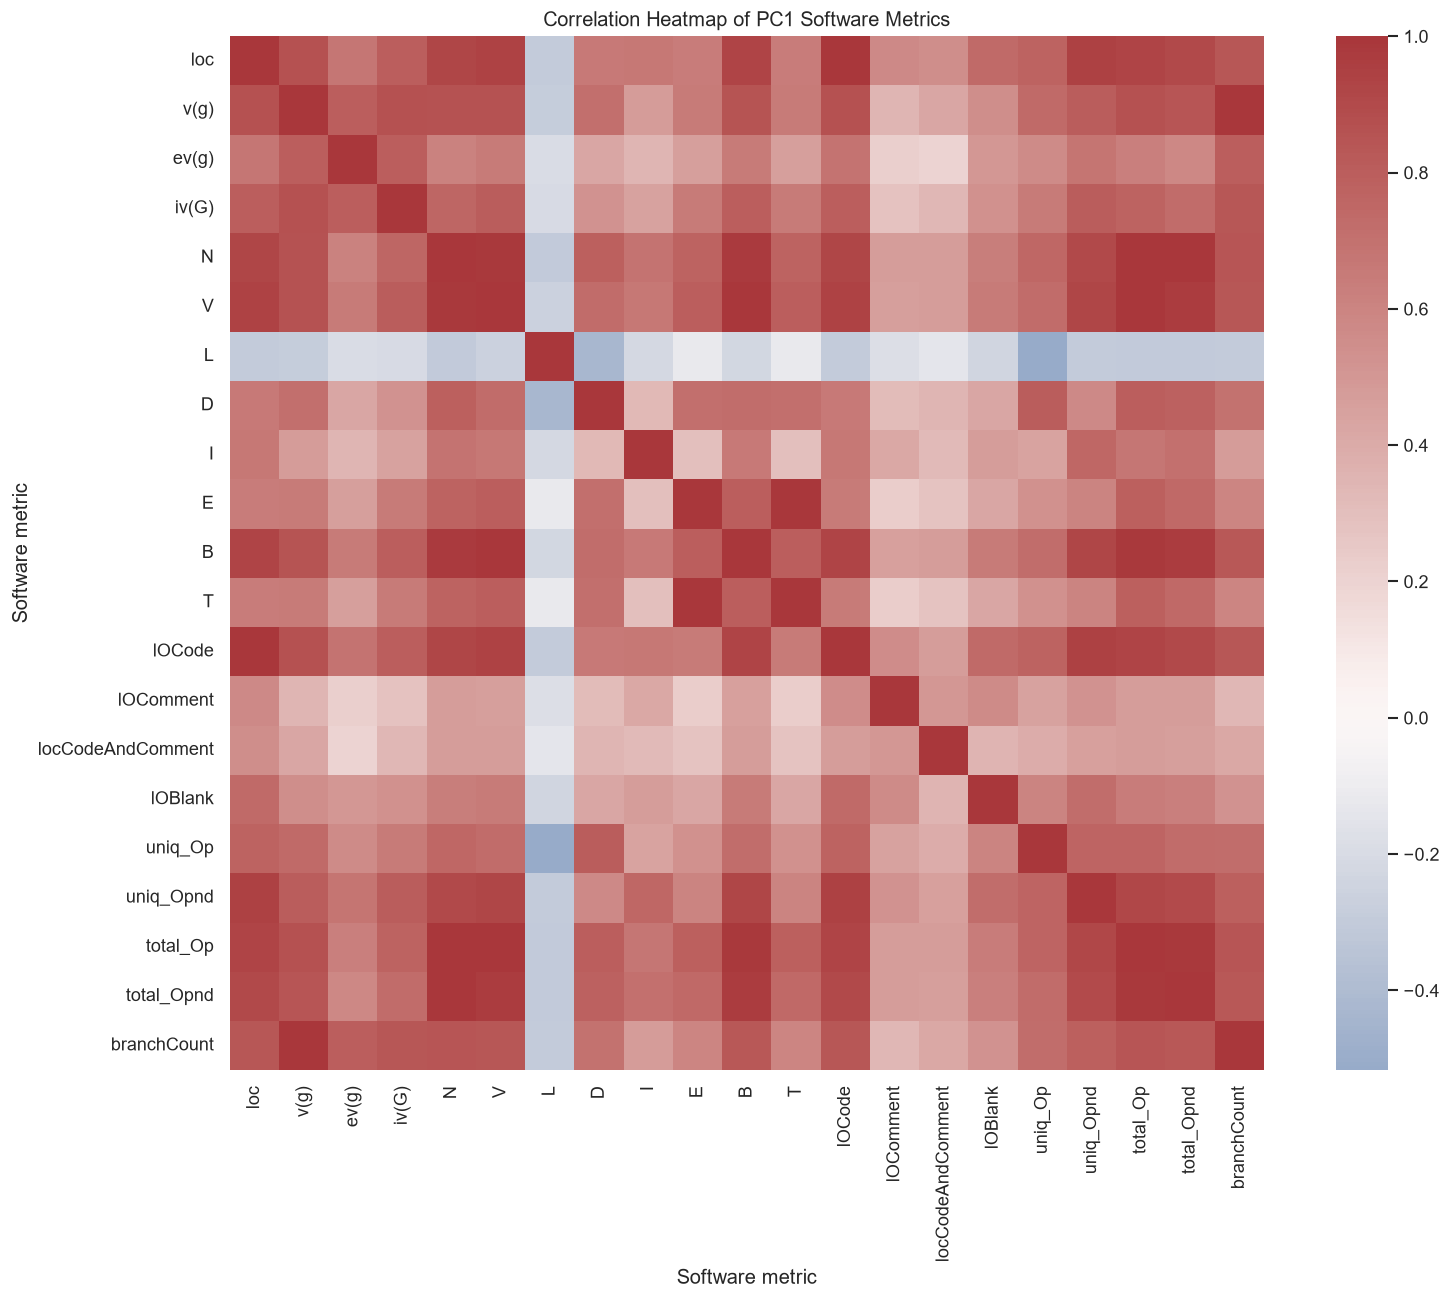

,feature_1,feature_2,correlation,absolute_correlation
200,E,T,1.0000,1.0000
102,N,total_Op,0.9974,0.9974
12,loc,lOCode,0.9965,0.9965
103,N,total_Opnd,0.9956,0.9956
115,V,B,0.9952,0.9952
41,v(g),branchCount,0.9916,0.9916
123,V,total_Op,0.9903,0.9903
89,N,V,0.9873,0.9873
397,total_Op,total_Opnd,0.9861,0.9861
228,B,total_Op,0.9850,0.9850


Key EDA Findings
- 1,109 modules, 21 numeric predictors, and 77 defective modules (6.94%).
- Missing values: 0; duplicate rows: 155; infinite values: 0.
- Most skewed features: T, E, ev(g), iv(G), V
- Strongest feature correlation: E and T (r = 1.000).
- Potential outliers are retained for Phase 4 review; no raw observations were removed.
- EDA does not establish causation; the Mann-Whitney results describe distribution differences only.


In [3]:
summary = numeric_df.describe().T
summary["median"] = numeric_df.median()
display(summary[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]].round(4))
quality = pd.Series({
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "infinite_values": int(np.isinf(numeric_df.to_numpy()).sum()),
    "constant_features": int((numeric_df.nunique() <= 1).sum()),
    "near_zero_variance_features": int((numeric_df.var() < 1e-6).sum()),
})
display(quality.to_frame("observed_value"))
variability = pd.DataFrame({
    "range": numeric_df.max() - numeric_df.min(),
    "skewness": numeric_df.skew(),
    "coefficient_of_variation": numeric_df.std() / numeric_df.mean().replace(0, np.nan),
}).sort_values("range", ascending=False)
display(variability.round(4))
rows = int(np.ceil(len(features) / 3))
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 3))
axes = np.asarray(axes).ravel()
for axis, feature in zip(axes, features):
    sns.histplot(numeric_df[feature], kde=True, ax=axis, color="#2a6f97")
    axis.set_title(feature)
    axis.set_xlabel("Metric value")
    axis.set_ylabel("Modules")
for axis in axes[len(features):]:
    axis.remove()
fig.suptitle("Distributions of PC1 Software Metrics", y=1.002)
fig.tight_layout()
fig.savefig(figure_dir / "feature_distributions.png", bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=numeric_df, orient="h", ax=ax, color="#8ecae6", fliersize=2)
ax.set_title("Box Plots of PC1 Software Metrics")
ax.set_xlabel("Metric value")
ax.set_ylabel("Software metric")
fig.tight_layout()
fig.savefig(figure_dir / "feature_boxplots.png", bbox_inches="tight")
plt.show()
q1, q3 = numeric_df.quantile(0.25), numeric_df.quantile(0.75)
iqr = q3 - q1
outlier_flags = numeric_df.lt(q1 - 1.5 * iqr) | numeric_df.gt(q3 + 1.5 * iqr)
outliers = outlier_flags.sum().sort_values(ascending=False)
display(pd.DataFrame({"outlier_count": outliers, "outlier_percentage": (outliers / len(df) * 100).round(2)}))
fig, ax = plt.subplots(figsize=(12, 4))
outliers.plot(kind="bar", ax=ax, color="#f4a261")
ax.set_title("IQR-Based Potential Outlier Counts")
ax.set_xlabel("Software metric")
ax.set_ylabel("Flagged observations")
fig.tight_layout()
fig.savefig(figure_dir / "iqr_outlier_counts.png", bbox_inches="tight")
plt.show()
labels = df[target].map({False: "Non-defective", True: "Defective"})
medians = numeric_df.assign(class_label=labels).groupby("class_label")[features].median().T
medians["absolute_median_difference"] = (medians["Defective"] - medians["Non-defective"]).abs()
top_features = medians.sort_values("absolute_median_difference", ascending=False).head(6).index.tolist()
display(medians.loc[top_features].round(4))
comparison_rows = []
for feature in features:
    defective = numeric_df.loc[df[target], feature]
    non_defective = numeric_df.loc[~df[target], feature]
    statistic, p_value = mannwhitneyu(defective, non_defective, alternative="two-sided")
    comparison_rows.append({"feature": feature, "defective_median": defective.median(), "non_defective_median": non_defective.median(), "mann_whitney_u": statistic, "p_value": p_value})
comparison = pd.DataFrame(comparison_rows).sort_values("p_value")
display(comparison.head(10).round(6))
plot_df = df.assign(class_label=labels).melt(id_vars="class_label", value_vars=top_features, var_name="metric", value_name="value")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, feature in zip(axes.ravel(), top_features):
    sns.boxplot(data=plot_df[plot_df["metric"] == feature], x="class_label", y="value", hue="class_label", legend=False, ax=axis, palette=["#356859", "#d1495b"])
    axis.set_title(feature)
    axis.set_xlabel("Module class")
    axis.set_ylabel("Metric value")
fig.suptitle("Largest Absolute Median Differences", y=1.02)
fig.tight_layout()
fig.savefig(figure_dir / "defective_nondefective_comparison.png", bbox_inches="tight")
plt.show()
correlations = numeric_df.corr()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(correlations, cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Correlation Heatmap of PC1 Software Metrics")
ax.set_xlabel("Software metric")
ax.set_ylabel("Software metric")
fig.tight_layout()
fig.savefig(figure_dir / "correlation_heatmap.png", bbox_inches="tight")
plt.show()
upper = correlations.where(np.triu(np.ones(correlations.shape), k=1).astype(bool))
pairs = upper.stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "correlation"]
pairs["absolute_correlation"] = pairs["correlation"].abs()
pairs = pairs.sort_values("absolute_correlation", ascending=False)
display(pairs.head(15).round(4))
most_skewed = variability["skewness"].abs().sort_values(ascending=False).head(5).index.tolist()
strongest = pairs.iloc[0]
print("Key EDA Findings")
print(f"- {len(df):,} modules, {len(features)} numeric predictors, and {int(counts.loc['Defective']):,} defective modules ({percentages.loc['Defective']:.2f}%).")
print(f"- Missing values: {quality.loc['missing_values']}; duplicate rows: {quality.loc['duplicate_rows']}; infinite values: {quality.loc['infinite_values']}.")
print("- Most skewed features:", ", ".join(most_skewed))
print(f"- Strongest feature correlation: {strongest.feature_1} and {strongest.feature_2} (r = {strongest.correlation:.3f}).")
print("- Potential outliers are retained for Phase 4 review; no raw observations were removed.")
print("- EDA does not establish causation; the Mann-Whitney results describe distribution differences only.")